In [1]:
# Установка зависимостей (запустите один раз)
# %pip install -r requirements.txt

### Простой агент

Этот ноутбук запускает ReAct-агента
Бэкенд (GigaChat или LM Studio) настраивается в `config.yaml`.

In [1]:
# Импорты
import yaml
from pprint import pprint
from langgraph.prebuilt import create_react_agent
from tools.tools import tools
from connections.clients import get_llm_client

In [2]:
# Загрузка конфигурации
with open('config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

recursion_limit = config.get('agent', {}).get('recursion_limit', 25)

print(f"Активный бэкенд: {config['active_backend']}")
print(f"Лимит рекурсии графа: {recursion_limit}")
pprint(config)

Активный бэкенд: lmstudio
Лимит рекурсии графа: 30
{'active_backend': 'lmstudio',
 'agent': {'recursion_limit': 30},
 'backends': {'gigachat': {'env_vars': {'access_token': 'JPY_API_TOKEN',
                                        'base_url': 'GIGACHAT_API_URL'},
                           'model': 'GigaChat-2-MAX',
                           'temperature': 0.1,
                           'timeout': 120},
              'lmstudio': {'base_url': 'http://localhost:1234/v1',
                           'model': 'openai/gpt-oss-20b',
                           'temperature': 0.3,
                           'timeout': 120}},
 'debug': {'log_dir': 'logs',
           'log_llm_messages': True,
           'log_prompts': True,
           'log_sessions': True,
           'log_state_events': True,
           'log_tool_params': True,
           'log_tool_results': True}}


In [3]:
# Создание LLM клиента
backend = config['active_backend']
llm = get_llm_client(backend, config)
print(f"LLM клиент создан: {type(llm).__name__}")

LLM клиент создан: ChatOpenAI


In [4]:
# Создание ReAct-агента
agent_executor = create_react_agent(
    model=llm,
    tools=tools
)
print("Агент создан успешно!")

Агент создан успешно!


C:\Users\accordij\AppData\Local\Temp\ipykernel_18464\1833556789.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


### Тестовые запросы

In [5]:
# Тест 1: Простое вычисление
query1 = "Сколько будет 52 умножить на 48?"
print(f"Запрос: {query1}\n")

messages = agent_executor.invoke({'messages': [query1]})['messages']
pprint(messages)
print(f"\nОтвет агента: {messages[-1].content}")

Запрос: Сколько будет 52 умножить на 48?

[TOOL] calculator params={"expression": "52 * 48"}
[TOOL] memory_append params={"text": "[calculator] 52 * 48 = 2496"}


c:\Users\accordij\Documents\proj\23_Agent_CDO3\tools\tools.py:52: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  memory_append(f"[calculator] {expression} = {output}")


[HumanMessage(content='Сколько будет 52 умножить на 48?', additional_kwargs={}, response_metadata={}, id='44d64d38-fbcb-4fd1-99a3-43f574fa0fc8'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '475023804', 'function': {'arguments': '{"expression":"52 * 48"}', 'name': 'calculator'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 780, 'total_tokens': 819, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'openai/gpt-oss-20b', 'id': 'chatcmpl-60x7cv1ieohgbtlp6z22ds', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019c2960-c545-74f0-a31d-cb058df9a768-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '52 * 48'}, 'id': '475023804', 'type': 'tool_call'}], usage_metadata={'input_tokens': 780, 'output_tokens': 39, 'total_tokens': 819, 'input_token_details': {}, 'output_token_details': {}}),

In [8]:
# Тест 3: Проверка работы калькулятора напрямую
from tools.tools import calculator, memory_read

print("Тест функции калькулятора напрямую:")
test_expr = "2 ** 10"
result = calculator.invoke(test_expr)
print(f"{test_expr} = {result}")
print("\nЖурнал памяти (последние 5 строк):")
print(memory_read.invoke({"limit": 5}))

Тест функции калькулятора напрямую:
[TOOL] calculator params={"expression": "2 ** 10"}
[TOOL] memory_append params={"text": "[calculator] 2 ** 10 = 1024"}
2 ** 10 = 1024

Журнал памяти (последние 5 строк):
[TOOL] memory_read params={"limit": 5}
[calculator] 52 * 48 = 2496
[calculator] 2 ** 10 = 1024
[calculator] 2 ** 10 = 1024
[calculator] 2 ** 10 = 1024


---

## Агент с графом состояний

Ниже используется StateGraph с двумя состояниями:
- **Work State**: основная работа с полным набором инструментов (calculator, ask_human, think, memory)
- **Summarize State**: подведение итогов с рефлексией (summarize, memory)

Переходы:
- Work → Work (циклически, пока задача не решена)
- Work → Summarize (когда агент говорит "ЗАДАЧА_РЕШЕНА")
- Summarize → END

In [8]:
# Импорт агента (построенного через движок)
from agents import build_agent, visualize_agent
from tools.tools import tools

# Подготовка инструментов
tools_dict = {tool.name: tool for tool in tools}

# Создание графа состояний
print("🔧 Создание графа состояний через движок...")
agent_name = "my_agent"
graph_agent = build_agent(agent_name, llm, tools_dict)
print("✓ Граф состояний создан успешно!")
print(f"  Агент: {agent_name}")
print(f"  Инструментов доступно: {len(tools_dict)}")

🔧 Создание графа состояний через движок...
✓ Граф состояний создан успешно!
  Агент: my_agent
  Инструментов доступно: 11


In [9]:
# Визуализация структуры агента
print(visualize_agent(agent_name, llm, tools_dict))

📊 Граф агента:

Состояния:
  • work (entry)
    Инструменты: calculator, ask_human, think, memory
    Описание: Основное рабочее состояние с полным набором инструментов
  • summarize
    Инструменты: summarize, memory
    Описание: Финальное состояние для рефлексии и подведения итогов

Переходы:
  • work → summarize (условный)
    Переход из рабочего состояния в состояние подведения итогов. Срабатывает, когда агент говорит 'ЗАДАЧА_РЕШЕНА'. Если условие не выполнено, агент остается в Work и продолжает работу.
  • summarize → END (условный)
    Безусловное завершение работы после подведения итогов. Состояние Summarize всегда переходит в END.


### Тестовые сценарии с графом состояний

In [10]:
# # Тест 1: Простое вычисление (без уточнений)
# print("=" * 60)
# print("ТЕСТ 1: Простое вычисление")
# print("=" * 60)

# query = "Вычисли 25 * 4 и сохрани результат в память"

# result = graph_agent.invoke({
#     'messages': [query],
#     'memory': {}
# })

# print("\n" + "=" * 60)
# print("РЕЗУЛЬТАТ:")
# print("=" * 60)
# print(f"\nПоследнее сообщение: {result['messages'][-1].content}")
# print(f"\nПамять агента: {result.get('memory', {})}")

### Визуализация графа состояний

In [11]:
# # Визуализация структуры графа
# try:
#     from IPython.display import Image, display
    
#     # Получаем mermaid-диаграмму графа
#     mermaid_diagram = graph_agent.get_graph().draw_mermaid()
#     print("Структура графа (Mermaid):")
#     print(mermaid_diagram)
    
#     # Если установлен graphviz, можно получить PNG
#     try:
#         png_data = graph_agent.get_graph().draw_mermaid_png()
#         display(Image(png_data))
#     except Exception:
#         print("\nДля визуализации PNG установите: pip install pygraphviz")
        
# except Exception as e:
#     print(f"Визуализация недоступна: {e}")

## Агент аудита проверки

Ниже создается граф состояний для анализа файлов проверки (docx/sql/py).

In [12]:
# Создание графа агента аудита
print("🔧 Создание графа аудита...")
audit_agent_name = "audit_agent"
audit_agent_graph = build_agent(audit_agent_name, llm, tools_dict)
print("✓ Граф аудита создан успешно!")
print(f"  Агент: {audit_agent_name}")

print(visualize_agent(audit_agent_name, llm, tools_dict))

🔧 Создание графа аудита...
✓ Граф аудита создан успешно!
  Агент: audit_agent
📊 Граф агента:

Состояния:
  • start_work (entry)
    Инструменты: ask_human, think, memory, list_data_folders, find_case_folder, list_case_files
    Описание: Поиск папки проверки и сбор списка файлов
  • analize_word
    Инструменты: read_docx_structure, memory, think
    Описание: Анализ docx файлов: реплики и таблицы
  • analize_sql
    Инструменты: read_sql_file, memory, think
    Описание: Анализ SQL скриптов на риски и проблемы
  • analize_py
    Инструменты: read_py_file, memory, think
    Описание: Анализ Python скриптов на риски и проблемы
  • self_check
    Инструменты: memory, think
    Описание: Проверка полноты обработки и выбор следующего шага
  • write_report
    Инструменты: memory, summarize
    Описание: Формирование итогового отчета

Переходы:
  • start_work → analize_word (условный)
    Переход после успешного выбора папки и сбора файлов
  • analize_word → analize_sql (условный)
    Перех

Структура графа (Mermaid):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	start_work(start_work)
	analize_word(analize_word)
	analize_sql(analize_sql)
	analize_py(analize_py)
	self_check(self_check)
	write_report(write_report)
	__end__([<p>__end__</p>]):::last
	__start__ --> start_work;
	analize_py -.-> self_check;
	analize_sql -.-> analize_py;
	analize_word -.-> analize_sql;
	self_check -.-> analize_py;
	self_check -.-> analize_sql;
	self_check -.-> analize_word;
	self_check -.-> write_report;
	start_work -.-> analize_word;
	write_report -. &nbsp;END&nbsp; .-> __end__;
	analize_py -.-> analize_py;
	analize_sql -.-> analize_sql;
	analize_word -.-> analize_word;
	self_check -.-> self_check;
	start_work -.-> start_work;
	write_report -.-> write_report;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



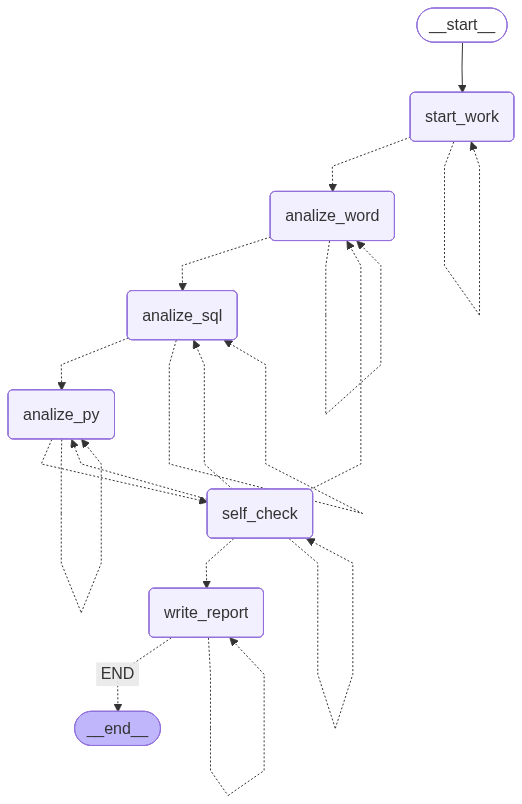

In [13]:
# Визуализация структуры графа агента аудита
try:
    from IPython.display import Image, display
    
    # Получаем mermaid-диаграмму графа
    mermaid_diagram = audit_agent_graph.get_graph().draw_mermaid()
    print("Структура графа (Mermaid):")
    print(mermaid_diagram)
    
    # Если установлен graphviz, можно получить PNG
    try:
        png_data = audit_agent_graph.get_graph().draw_mermaid_png()
        display(Image(png_data))
    except Exception:
        print("\nДля визуализации PNG установите: pip install pygraphviz")
        
except Exception as e:
    print(f"Визуализация недоступна: {e}")

In [ ]:
# Интерактивный запуск агента аудита
# print("Введите запрос. Пример: 'Проверь кейс 99-41116'")
# user_query = input("Запрос: ")
user_query = "Запрос: Проверь кейс 99-41116"

result = audit_agent_graph.invoke(
    {
        'messages': [user_query],
        'memory': {}
    },
    config={"recursion_limit": recursion_limit}
)

print("\nПоследнее сообщение:")
print(result['messages'][-1].content)
print("\nПамять:")
print(result.get('memory', {}))

[STATE] START -> start_work
[TOOL] ask_human params={"question": "Пожалуйста, уточните номер проверки (например, 99-41116)."}

🤔 Вопрос агента: Пожалуйста, уточните номер проверки (например, 99-41116).
[TOOL] find_case_folder params={"case_input": "99-41116", "data_root": "data"}
[TOOL] list_case_files params={"case_folder": "data\\99-41116"}
[STATE] start_work -> analize_word
[TOOL] read_docx_structure params={"docx_path": "audit_report_99-41116.docx"}
[TOOL] read_docx_structure params={"docx_path": "data/99-41116/audit_report_99-41116.docx"}
[TOOL] memory params={"action": "save", "key": "docx_notes", "value": "{\"audit_report_99-41116.docx\":{\"replica_titles\":[],\"table_titles\":[]}}"}
[STATE] analize_word -> analize_sql
[TOOL] memory params={"action": "get", "key": "docx_structure", "value": ""}
[TOOL] read_sql_file params={"sql_path": "data/99-41116/query_01.sql"}
[TOOL] read_sql_file params={"sql_path": "data/99-41116/query_02.sql"}
[TOOL] memory params={"action": "save", "key"